<a href="https://colab.research.google.com/github/NooraZhang/IBD-diet-and-inflammation-analysis/blob/main/IBDMDB_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="font-size: 50px;">Dietary Intake and Inflammatory Activity in IBD</h1>

## Research Question
Is dietary intake associated with intestinal inflammation severity, as measured by fecal calprotectin?

## Data Source
The metadata were obtained from the Inflammatory Bowel Disease Multi-omics Database (IBDMDB). Each participant was followed longitudinally, so one participant may contribute observations from multiple visits.

# IBDMDB

IBDMDB is a dataset that contains information about the patient’s food intake, microbiome compositions, patient’s personal information and the inflammation indexes. It is used to record the status and severity of inflammation for different IBD patients.

#Import the file


In [1]:
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "lotas-ai/hutlab-demo/"
    "9189026f2cb66883690c57ad73ad9d96b02a861c/"
    "data/hmp2_metadata_2018-08-20.csv"
)

df_raw = pd.read_csv(DATA_URL, low_memory=False)

print("Raw dataset shape:", df_raw.shape)

assert df_raw.shape == (5533, 490), (
    f"Unexpected dataset shape: {df_raw.shape}"
)

Raw dataset shape: (5533, 490)


In [2]:
df = df_raw.copy()
print(df.shape)

(5533, 490)


# Eliminate the unuseful variables

The raw IBDMDB metadata contained 5,533 rows and 490 columns. I selected 31 variables relevant to the research question. These included participant characteristics, medication use, dietary intake variables, diagnosis, and inflammation measurements. Fecal calprotectin was selected as the main measure of intestinal inflammation because it reflects inflammation in the gastrointestinal tract and it contains fewer missing values than other inflammation markers.

In [3]:
import pandas as pd
df = df_raw.copy()

columns_to_keep = [
    'Participant ID', 'week_num', 'diagnosis', 'sex', 'race', 'BMI',
    'site_sub_coll',
    'Age at diagnosis', 'Antibiotics',
    'Immunosuppressants (e.g. oral corticosteroids)',
    'fecalcal_ng_ml', 'fecalcal', 'is_inflamed', 'hbi', 'sccai',
    'CRP (mg/L)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df = df[columns_to_keep]
print(df.shape)
print(df.head())

(5533, 32)
  Participant ID  week_num diagnosis     sex   race  BMI site_sub_coll  \
0          C3001       2.0        CD  Female  White  NaN     C3001CSC1   
1          C3001       2.0        CD  Female  White  NaN     C3001CSC2   
2          C3002       0.0        CD  Female  White  NaN     C3002CSC1   
3          C3002       0.0        CD  Female  White  NaN     C3002CSC2   
4          C3002       0.0        CD  Female  White  NaN     C3002CSC3   

   Age at diagnosis Antibiotics  \
0              28.0          No   
1              28.0          No   
2              47.0          No   
3              47.0          No   
4              47.0          No   

  Immunosuppressants (e.g. oral corticosteroids)  ...  \
0                                             No  ...   
1                                             No  ...   
2                                             No  ...   
3                                             No  ...   
4                                             No

# Filter out the samples with no data of fecal calprotectin


Among the 5,533 records, 1,883 had a valid fecal calprotectin value. Records without fecal calprotectin were removed because they could not be used to examine the relationship between diet and inflammation.

In [4]:
inflammation_vars = ['fecalcal', 'fecalcal_ng_ml', 'is_inflamed', 'hbi', 'sccai', 'CRP (mg/L)']

for var in inflammation_vars:
    total = len(df)
    missing = df[var].isna().sum()
    valid = total - missing
    pct_missing = missing/total*100
    print(f"{var}: {valid} valid ({pct_missing:.1f}% missing)")

fecalcal: 1883 valid (66.0% missing)
fecalcal_ng_ml: 121 valid (97.8% missing)
is_inflamed: 881 valid (84.1% missing)
hbi: 2145 valid (61.2% missing)
sccai: 1335 valid (75.9% missing)
CRP (mg/L): 669 valid (87.9% missing)


In [5]:

df_clean2 = df[df['fecalcal'].notna()]
print(df_clean2.shape)
print(df_clean2['diagnosis'].value_counts())
print(df_clean2['fecalcal'].head(10))

(1883, 32)
diagnosis
CD        928
UC        512
nonIBD    443
Name: count, dtype: int64
522    193.89000
523     61.34000
524    115.27000
525     23.20350
526     37.17836
527     48.90000
528    179.22000
529     54.33000
530     15.97901
531     14.51068
Name: fecalcal, dtype: float64


# Print the number of missing data for each variable

In [6]:
# 用fecalcal过滤
df_clean = df[df['fecalcal'].notna()].copy()

# 检查missing values
print(df_clean.isnull().sum())

Participant ID                                                                         0
week_num                                                                               0
diagnosis                                                                              0
sex                                                                                    0
race                                                                                   0
BMI                                                                                 1883
site_sub_coll                                                                          0
Age at diagnosis                                                                     458
Antibiotics                                                                            0
Immunosuppressants (e.g. oral corticosteroids)                                         0
fecalcal_ng_ml                                                                      1883
fecalcal             

# Delete the variables with no data


Variables that were completely missing after this filtering step, including BMI, fecalcal_ng_ml, is_inflamed, and CRP, were also removed.

Records with missing values in any of the 16 dietary variables were excluded. After this complete-case filtering, the analysis contained 1,739 records.

In [7]:


df_clean = df_clean.drop(columns=['BMI', 'fecalcal_ng_ml', 'is_inflamed', 'CRP (mg/L)'])


dietary_cols = [
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df_clean = df_clean.dropna(subset=dietary_cols)
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(1739, 28)
diagnosis
CD        858
UC        468
nonIBD    413
Name: count, dtype: int64


In [8]:
# Convert dietary responses from text to ordinal scores

frequency_map = {
    'No, I did not consume these products in the last 7 days': 0,
    'Within the past 4 to 7 days': 1,
    'Within the past 2 to 3 days': 2,
    'Yesterday, 1 to 2 times': 3,
    'Yesterday, 3 or more times': 4
}

for col in dietary_cols:
    df_clean[col] = df_clean[col].replace(frequency_map)
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors='coerce'
    )

print("Dietary variables converted:")
print(df_clean[dietary_cols].dtypes)

Dietary variables converted:
Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries     int64
Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)    int64
Red meat (beef, hamburger, pork, lamb)                                              int64
White meat (chicken, turkey, etc.)                                                  int64
Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)                   int64
Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)       int64
Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)          int64
Dairy (milk, cream, ice cream, cheese, cream cheese)                                int64
Sweets (pies, jam, chocolate, cake, cookies, etc.)                                  int64
Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)      int64
Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc) 

/tmp/ipykernel_1424/2902668986.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace(frequency_map)


In [9]:
sample_counts = df_clean['site_sub_coll'].value_counts()

print("Total rows:", len(df_clean))
print("Unique collection samples:", df_clean['site_sub_coll'].nunique())
print("Samples appearing more than once:", (sample_counts > 1).sum())
print("Maximum repetitions:", sample_counts.max())

display(sample_counts.head(10))

Total rows: 1739
Unique collection samples: 582
Samples appearing more than once: 460
Maximum repetitions: 7


,count
site_sub_coll,
C3004C19,7
P6005C5,7
H4014C5,7
H4013C14,7
M2068C5,7
M2068C9,7
M2064C5,6
P6018C23,6
P6009C1,6


In [10]:
variables_to_check = dietary_cols + ['fecalcal']

variation_check = (
    df_clean
    .groupby('site_sub_coll')[variables_to_check]
    .nunique(dropna=False)
)

different_samples = variation_check[
    variation_check.gt(1).any(axis=1)
]

print(
    "Collection samples with different diet or fecalcal values:",
    len(different_samples)
)

display(different_samples.head(10))

Collection samples with different diet or fecalcal values: 0


,"Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries","Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)","Red meat (beef, hamburger, pork, lamb)","White meat (chicken, turkey, etc.)","Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)","Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)","Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)","Dairy (milk, cream, ice cream, cheese, cream cheese)","Sweets (pies, jam, chocolate, cake, cookies, etc.)","Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)","Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",Eggs,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna","Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)",Water,"Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)",fecalcal
site_sub_coll,,,,,,,,,,,,,,,,,


# Remove the dulicates of samples


In [11]:
# Save all 1,739 cleaned records
df_clean_all_records = df_clean.copy()

# Keep one row per collection sample for diet–fecalcal analysis
df_clean = (
    df_clean
    .drop_duplicates(
        subset='site_sub_coll',
        keep='first'
    )
    .copy()
)

print("Records before deduplication:", len(df_clean_all_records))
print("Unique collection samples used in analysis:", len(df_clean))

assert len(df_clean) == 582, (
    f"Expected 582 collection samples, but found {len(df_clean)}"
)

Records before deduplication: 1739
Unique collection samples used in analysis: 582


# Visualization of the distribution of fecalcal

count    582.000000
mean     119.906050
std      114.348626
min        3.450000
25%       16.983988
50%       68.526310
75%      214.280000
max      493.700000
Name: fecalcal, dtype: float64


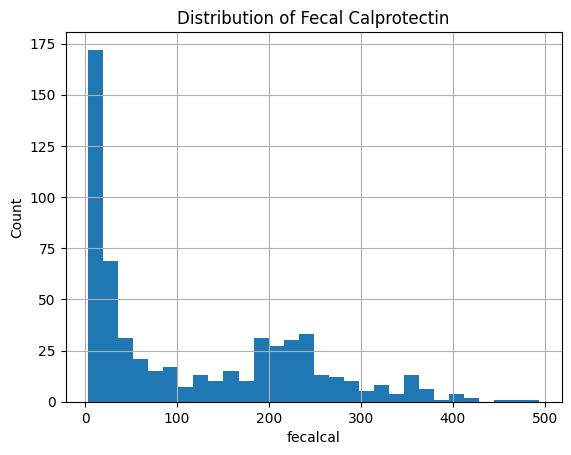

In [12]:
print(df_clean['fecalcal'].describe())

import matplotlib.pyplot as plt
df_clean['fecalcal'].hist(bins=30)
plt.title('Distribution of Fecal Calprotectin')
plt.xlabel('fecalcal')
plt.ylabel('Count')
plt.show()

Fecal calprotectin had a right-skewed distribution. The median value was 54.74 μg/g, while the mean was 116.57 μg/g. This difference indicates that a smaller number of records with high fecal calprotectin values increased the mean. The observed values ranged from 3.45 to 493.70 μg/g.

# Log-transformed visualization of the distribution of fecalcal

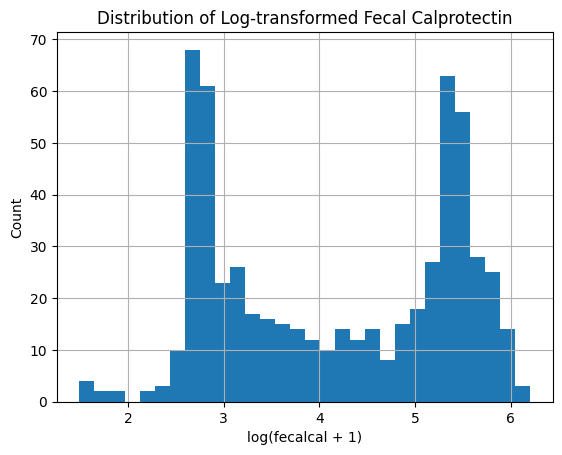

In [13]:
import numpy as np

# Log transformation
df_clean['fecalcal_log'] = np.log(df_clean['fecalcal'] + 1)


df_clean['fecalcal_log'].hist(bins=30)
plt.title('Distribution of Log-transformed Fecal Calprotectin')
plt.xlabel('log(fecalcal + 1)')
plt.ylabel('Count')
plt.show()

A log-transformed graph is generated to show the distribution of fecal calprotectin more clearly. It shows that there are two peak values. The first peak value would be participants who have low level of fecal calprotectin, while the second one may indicate the participants who are experiencing a flare-up period of IBD.

#Result of the Spearman statistical test

---



Dietary intake was recorded as an ordinal categorical variable. I converted the categories into numerical scores from 0 to 4 according to their order.

Spearman correlation test was carried out in order to investigate the assosiation between food and fecal calprotectin. Correlation is used to show the relationship between food and fecal calprotectin. A positive value indicates that the intake of the food is associated with increased level of fecal calprotectin, while a negative value indicates that the intake of the food is associated with a decreased level of fecal calprotectin.

P-value is used to indicate whether the correlation between food and fecal calprotecitn is statistically significant (p < 0.05：statistically significant,
p ≥ 0.05：not statistically significant).

In [14]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

# 每次运行时清空旧结果
results = []

for col in dietary_cols:
    temp = df_clean[[col, 'fecalcal']].dropna()

    corr, pval = spearmanr(
        temp[col],
        temp['fecalcal']
    )

    results.append({
        'Food': col,
        'Correlation': corr,
        'P-value': pval
    })

# 重新创建，而不是追加到旧表
results_df = pd.DataFrame(results)

# Bonferroni correction（共16次检验）
results_df['Adjusted P-value'] = multipletests(
    results_df['P-value'],
    method='bonferroni'
)[1]

results_df['Significant'] = np.where(
    results_df['Adjusted P-value'] < 0.05,
    'Yes',
    'No'
)

results_df = results_df.sort_values(
    'Correlation',
    ascending=False
).reset_index(drop=True)

print("Number of tests:", len(results_df))

display(
    results_df.style.format({
        'Correlation': '{:.3f}',
        'P-value': '{:.4g}',
        'Adjusted P-value': '{:.4g}'
    })
)

Number of tests: 16


,Food,Correlation,P-value,Adjusted P-value,Significant
0,"Processed meat (other red or white meat such as lunch meat, ham, salami, bologna",0.047,0.2571,1,No
1,"Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)",0.029,0.4868,1,No
2,"Dairy (milk, cream, ice cream, cheese, cream cheese)",-0.014,0.7277,1,No
3,Eggs,-0.017,0.6738,1,No
4,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",-0.025,0.555,1,No
5,"Sweets (pies, jam, chocolate, cake, cookies, etc.)",-0.052,0.2129,1,No
6,"Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)",-0.076,0.06632,1,No
7,"Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)",-0.079,0.05777,0.9243,No
8,"White meat (chicken, turkey, etc.)",-0.097,0.01965,0.3144,No
9,"Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)",-0.105,0.01095,0.1752,No


# Visualization of the Spearman Correlation Results (Only Dietary Variables Significantly Associated with Fecal Calprotectin Are Included)

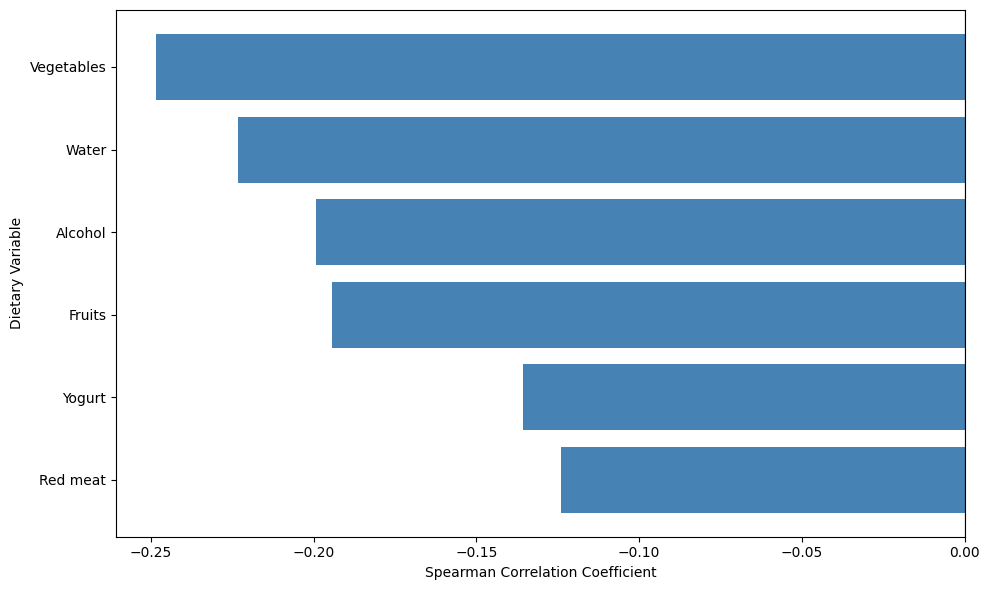

In [37]:
import matplotlib.pyplot as plt

# Select significant Spearman results
sig_results = results_df.loc[
    results_df["Adjusted P-value"] < 0.05,
    ["Food", "Correlation"]
].copy()

# Match names according to their text rather than column position
food_labels = [
    "Processed meat",
    "Soft drinks",
    "Whole grains",
    "White meat",
    "Red meat",
    "Vegetables",
    "Fruits",
    "Alcohol",
    "Yogurt",
    "Starch",
    "Sweets",
    "Dairy",
    "Beans",
    "Eggs",
    "Fish",
    "Water"
]

def shorten_food_name(full_name):
    for label in food_labels:
        if full_name.startswith(label):
            return label
    return full_name

sig_results["Food_short"] = (
    sig_results["Food"]
    .apply(shorten_food_name)
)

# Strongest negative correlations at the top
sig_results = sig_results.sort_values("Correlation")

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "tomato" if value > 0 else "steelblue"
    for value in sig_results["Correlation"]
]

ax.barh(
    sig_results["Food_short"],
    sig_results["Correlation"],
    color=colors
)

ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)

# No embedded title because the APA figure title goes above the image in Word
ax.set_xlabel("Spearman Correlation Coefficient")
ax.set_ylabel("Dietary Variable")

plt.tight_layout()

plt.savefig(
    "significant_spearman_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Group the samples into high inflammation level，gray zone and low inflammation level

The samples were categorized into three groups based on the value of fecal calprotectin: low inflammation (<50 μg/g), gray zone (50–250 μg/g), and high inflammation (>250 μg/g).

In [16]:
import numpy as np

df_clean["inflammation_level"] = np.select(
    [
        df_clean["fecalcal"] < 50,
        (df_clean["fecalcal"] >= 50) &
        (df_clean["fecalcal"] <= 250),
        df_clean["fecalcal"] > 250
    ],
    [
        "Low",
        "Gray Zone",
        "High"
    ],
    default="Missing"
)


group_order = ["Low", "Gray Zone", "High"]

df_clean["inflammation_level"] = pd.Categorical(
    df_clean["inflammation_level"],
    categories=group_order,
    ordered=True
)

print(df_clean["inflammation_level"].value_counts().sort_index())

inflammation_level
Low          269
Gray Zone    232
High          81
Name: count, dtype: int64


## Compare Mean Dietary Frequency Scores Across Inflammation Groups

This score shows how frequently each food was consumed, on average, within each inflammation group.

In [17]:
# Calculate mean dietary frequency scores for each group
diet_by_inflammation = (
    df_clean
    .dropna(subset=["inflammation_level"])
    .groupby(
        "inflammation_level",
        observed=True
    )[dietary_cols]
    .mean()
    .reindex(group_order)
    .round(2)
)

print(diet_by_inflammation)

                    Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries  \
inflammation_level                                                                                    
Low                                                              2.39                                 
Gray Zone                                                        1.94                                 
High                                                             1.94                                 

                    Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
inflammation_level                                                                                     
Low                                                              2.81                                  
Gray Zone                                                        2.41                                  
High                                                             2.1

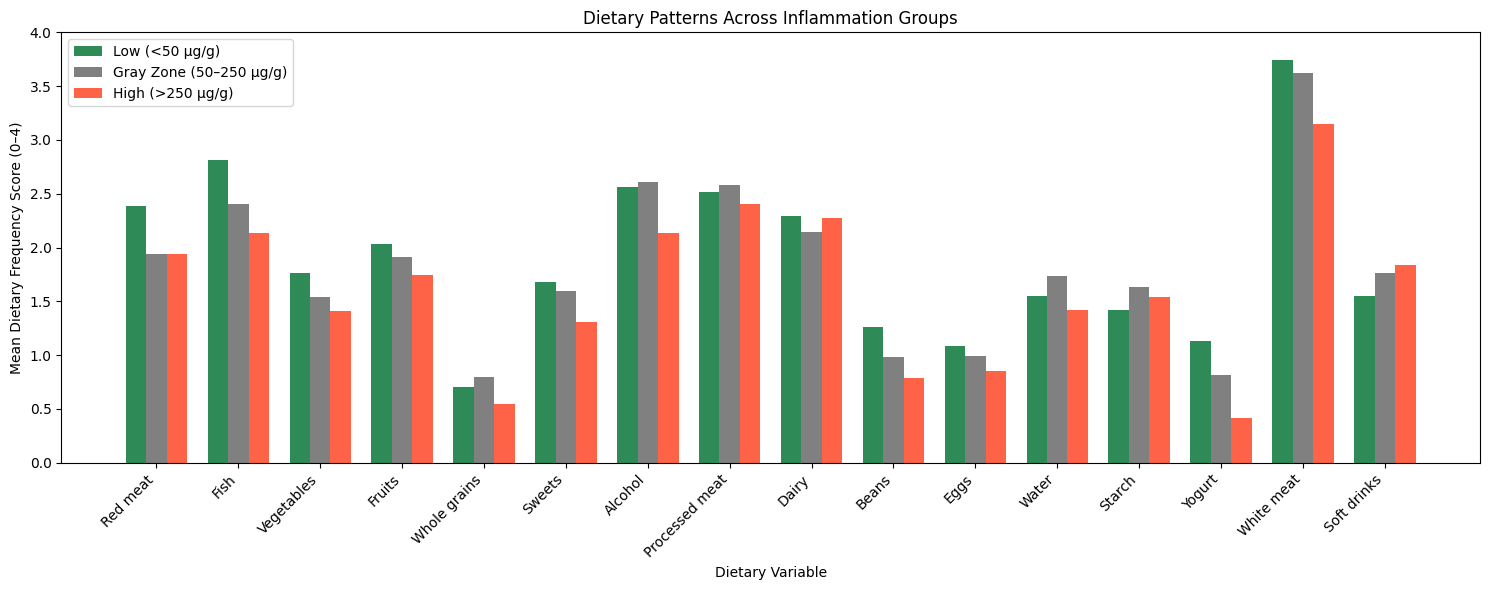

In [18]:
import matplotlib.pyplot as plt
import numpy as np

group_order = ["Low", "Gray Zone", "High"]

diet_by_inflammation = (
    df_clean
    .groupby("inflammation_level", observed=True)[dietary_cols]
    .mean()
    .reindex(group_order)
)

food_short = [
    "Red meat", "Fish", "Vegetables", "Fruits",
    "Whole grains", "Sweets", "Alcohol", "Processed meat",
    "Dairy", "Beans", "Eggs", "Water",
    "Starch", "Yogurt", "White meat", "Soft drinks"
]

x = np.arange(len(food_short))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(
    x - width,
    diet_by_inflammation.loc["Low"],
    width,
    label="Low (<50 μg/g)",
    color="seagreen"
)

ax.bar(
    x,
    diet_by_inflammation.loc["Gray Zone"],
    width,
    label="Gray Zone (50–250 μg/g)",
    color="gray"
)

ax.bar(
    x + width,
    diet_by_inflammation.loc["High"],
    width,
    label="High (>250 μg/g)",
    color="tomato"
)

ax.set_title("Dietary Patterns Across Inflammation Groups")
ax.set_xlabel("Dietary Variable")
ax.set_ylabel("Mean Dietary Frequency Score (0–4)")
ax.set_xticks(x)
ax.set_xticklabels(food_short, rotation=45, ha="right")
ax.set_ylim(0, 4)
ax.legend()

plt.tight_layout()
plt.show()

# Kruskal-Wallis test between three groups of participants with different inflammation level and their food intake

In [19]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

group_order = [
    'Low',
    'Gray Zone',
    'High'
]

kw_results = []

for food in dietary_cols:

    groups = [
        df_clean.loc[
            df_clean['inflammation_level'] == group,
            food
        ].dropna()

        for group in group_order
    ]

    h_stat, p_value = kruskal(*groups)

    kw_results.append({
        'Food': food,
        'H statistic': h_stat,
        'P-value': p_value
    })

kw_results_df = pd.DataFrame(kw_results)

# Bonferroni correction for 16 tests
kw_results_df['Adjusted P-value'] = multipletests(
    kw_results_df['P-value'],
    method='bonferroni'
)[1]

kw_results_df['Significant'] = np.where(
    kw_results_df['Adjusted P-value'] < 0.05,
    'Yes',
    'No'
)

kw_results_df = (
    kw_results_df
    .sort_values('Adjusted P-value')
    .reset_index(drop=True)
)

print("Number of tests:", len(kw_results_df))

display(
    kw_results_df.style.format({
        'H statistic': '{:.3f}',
        'P-value': '{:.4g}',
        'Adjusted P-value': '{:.4g}'
    })
)

Number of tests: 16


,Food,H statistic,P-value,Adjusted P-value,Significant
0,"Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)",32.404,9.196e-08,1.471e-06,Yes
1,Water,31.546,1.412e-07,2.259e-06,Yes
2,"Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries",23.914,6.414e-06,0.0001026,Yes
3,"Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)",20.711,3.182e-05,0.0005091,Yes
4,"Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)",13.026,0.001484,0.02375,Yes
5,"Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)",11.622,0.002995,0.04792,Yes
6,"Red meat (beef, hamburger, pork, lamb)",7.835,0.01989,0.3182,No
7,"Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)",5.806,0.05486,0.8778,No
8,"White meat (chicken, turkey, etc.)",5.583,0.06132,0.9811,No
9,"Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)",5.550,0.06236,0.9978,No


# Dunn's post-hoc test that compares the food of intake between two groups each time

In [20]:
%pip -q install scikit-posthocs

In [21]:
import scikit_posthocs as sp
import pandas as pd

# 只选择 Kruskal–Wallis 检验校正后显著的食物
significant_foods = kw_results_df.loc[
    kw_results_df["Significant"] == "Yes",
    "Food"
].tolist()

group_order = ["Low", "Gray Zone", "High"]

dunn_results = {}

for food in significant_foods:

    # 删除该食物或炎症组存在缺失值的行
    temp = df_clean[
        ["inflammation_level", food]
    ].dropna()

    # Dunn's pairwise test，并进行 Bonferroni 校正
    dunn_table = sp.posthoc_dunn(
        temp,
        val_col=food,
        group_col="inflammation_level",
        p_adjust="bonferroni"
    )

    # 按 Low、Gray Zone、High 的顺序排列
    dunn_table = dunn_table.reindex(
        index=group_order,
        columns=group_order
    )

    dunn_results[food] = dunn_table

    print("\nFood:", food)
    display(dunn_table.style.format("{:.4f}"))


Food: Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)


,Low,Gray Zone,High
Low,1.0000,0.0000,0.0000
Gray Zone,0.0000,1.0000,0.6985
High,0.0000,0.6985,1.0000



Food: Water


,Low,Gray Zone,High
Low,1.0000,0.1203,0.0000
Gray Zone,0.1203,1.0000,0.0001
High,0.0000,0.0001,1.0000



Food: Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries


...

,Low,Gray Zone,High
Low,1.0000,0.0139,0.0001
Gray Zone,0.0139,1.0000,0.0735
High,0.0001,0.0735,1.0000



Food: Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)


,Low,Gray Zone,High
Low,1.0000,1.0000,0.0026
Gray Zone,1.0000,1.0000,0.0018
High,0.0026,0.0018,1.0000



Food: Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)


,Low,Gray Zone,High
Low,1.0000,0.0348,0.0083
Gray Zone,0.0348,1.0000,0.7071
High,0.0083,0.7071,1.0000


# The Dunn’s test determined which pairs of groups differed significantly, while these descriptive statistics were used to determine which group reported higher or lower dietary frequency scores. This step did not perform an additional statistical significance test.

In [22]:
group_summary = (
    df_clean
    .groupby("inflammation_level")[significant_foods]
    .agg(["median", "mean", "count"])
    .reindex(["Low", "Gray Zone", "High"])
)

display(group_summary.round(2))

/tmp/ipykernel_1424/181924057.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("inflammation_level")[significant_foods]


Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
                                                                                             median   
inflammation_level                                                                                    
Low                                                               3.0                                 
Gray Zone                                                         3.0                                 
High                                                              3.0                                 

                                Water              \
                    mean count median  mean count   
inflammation_level                                  
Low                 2.81   269    4.0  3.74   269   
Gray Zone           2.41   232    4.0  3.62   232   
High                2.14    81    3.0  3.15    81   

                   Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries  \
                                                                                            median   
inflammation_level                                                                                   
Low                                                               3.0                                
Gray Zone                                                         2.0                                
High                                                              2.0                                

                                \
                    mean count   
inflammation_level               
Low                 2.39   269   
Gray Zone           1.94   232   
High                1.94    81   

                   Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)  \
                                                                               median   
inflammation_level                                                                      
Low                                                               0.0                   
Gray Zone                                                         0.0                   
High                                                              0.0                   

                                \
                    mean count   
inflammation_level               
Low                 1.13   269   
Gray Zone           0.81   232   
High                0.42    81   

                   Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)  \
                                                                                       median   
inflammation_level                                                                              
Low                                                               3.0                           
Gray Zone                                                         3.0                           
High                                                              2.0                           

                                \
                    mean count   
inflammation_level               
Low                 2.56   269   
Gray Zone           2.61   232   
High                2.14    81   

                   Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)  \
                                                                                           median   
inflammation_level                                                                                  
Low                                                               1.0                               
Gray Zone                                                         0.0                               
High                                                              0.0                               

                                
                    mean count  
inflammation_level              
Low                 1.26   26

# Dietary Differences Across Inflammation Groups: Kruskal–Wallis and Dunn’s Post-hoc Test Results

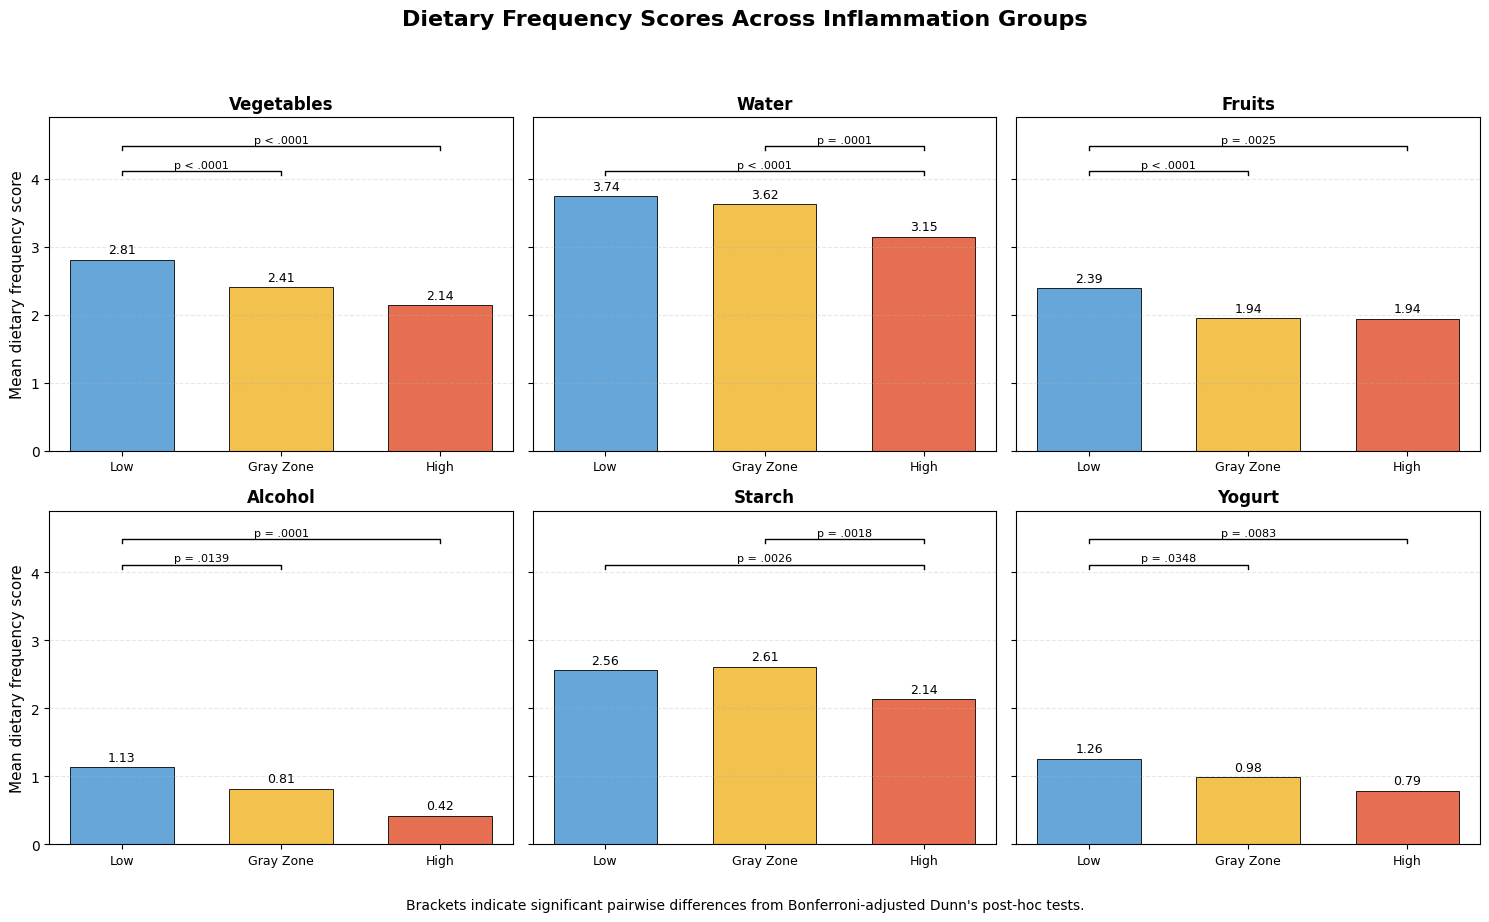

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Fixed order of inflammation groups
group_order = ["Low", "Gray Zone", "High"]

# Find the full column names automatically
plot_foods = {
    "Vegetables": next(
        food for food in significant_foods
        if food.startswith("Vegetables")
    ),
    "Water": next(
        food for food in significant_foods
        if food.startswith("Water")
    ),
    "Fruits": next(
        food for food in significant_foods
        if food.startswith("Fruits")
    ),
    "Alcohol": next(
        food for food in significant_foods
        if food.startswith("Alcohol")
    ),
    "Starch": next(
        food for food in significant_foods
        if food.startswith("Starch")
    ),
    "Yogurt": next(
        food for food in significant_foods
        if food.startswith("Yogurt")
    )
}

# Significant pairwise comparisons from Dunn's test
# Group positions: Low = 0, Gray Zone = 1, High = 2
significant_pairs = {
    "Vegetables": [
        (0, 1, "p < .0001"),
        (0, 2, "p < .0001")
    ],
    "Water": [
        (0, 2, "p < .0001"),
        (1, 2, "p = .0001")
    ],
    "Fruits": [
        (0, 1, "p < .0001"),
        (0, 2, "p = .0025")
    ],
    "Alcohol": [
        (0, 1, "p = .0139"),
        (0, 2, "p = .0001")
    ],
    "Starch": [
        (0, 2, "p = .0026"),
        (1, 2, "p = .0018")
    ],
    "Yogurt": [
        (0, 1, "p = .0348"),
        (0, 2, "p = .0083")
    ]
}

# Function for adding significance brackets
def add_significance_bracket(ax, x1, x2, y, label):
    bracket_height = 0.06

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bracket_height, y + bracket_height, y],
        color="black",
        linewidth=1
    )

    ax.text(
        (x1 + x2) / 2,
        y + bracket_height + 0.02,
        label,
        ha="center",
        va="bottom",
        fontsize=8
    )

# Colours for the three inflammation groups
colors = ["#66A6D9", "#F2C14E", "#E76F51"]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharey=True
)

axes = axes.flatten()

for ax, (short_name, full_name) in zip(
    axes,
    plot_foods.items()
):

    # Calculate the mean score in each inflammation group
    means = (
        df_clean
        .groupby(
            "inflammation_level",
            observed=False
        )[full_name]
        .mean()
        .reindex(group_order)
    )

    x_positions = np.arange(len(group_order))

    bars = ax.bar(
        x_positions,
        means.values,
        color=colors,
        width=0.65,
        edgecolor="black",
        linewidth=0.6
    )

    # Add the mean value above each bar
    for bar, value in zip(bars, means.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.05,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # Add the two significant Dunn comparisons
    bracket_levels = [4.05, 4.42]

    for level, (x1, x2, p_label) in zip(
        bracket_levels,
        significant_pairs[short_name]
    ):
        add_significance_bracket(
            ax,
            x1,
            x2,
            level,
            p_label
        )

    ax.set_title(short_name, fontsize=12, fontweight="bold")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(group_order, fontsize=9)
    ax.set_ylim(0, 4.9)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

# Y-axis labels for the left-hand plots
axes[0].set_ylabel("Mean dietary frequency score", fontsize=11)
axes[3].set_ylabel("Mean dietary frequency score", fontsize=11)

fig.suptitle(
    "Dietary Frequency Scores Across Inflammation Groups",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

fig.text(
    0.5,
    0.01,
    "Brackets indicate significant pairwise differences from "
    "Bonferroni-adjusted Dunn's post-hoc tests.",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 0.97])

# Save a high-resolution version
plt.savefig(
    "dunn_posthoc_group_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

This graph shows the result of the Kruskal-Wallis test and the Dunn's test. The Krusal-Wallis test is used to determine which foods have statistically significant variance across the three groups of patients. Only the food with the frequency score that varies significantly between three groups of patients are kept. After that, tbe mean dietary frequency scores of these foods are calculated. Dunn's test is used to determine that variation of mean frequency score of a food across two groups. Only the variations that are statistically significant are shown in the graph as brackets and p-values.

#Linear Regression Model

 This model was used to investigate the linear relationship between the diet and the inflammation level.

In [24]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# --------------------------------------------------
# 1. Identify the participant ID column
# --------------------------------------------------

participant_candidates = [
    "Participant ID",
    "participant_id",
    "subject_id"
]

participant_col = next(
    (
        col for col in participant_candidates
        if col in df_clean.columns
    ),
    None
)

if participant_col is None:
    raise ValueError(
        "Participant ID column was not found. "
        "Please check the column name."
    )

# --------------------------------------------------
# 2. Select available control variables
# --------------------------------------------------

numeric_control_candidates = [
    "age",
    "BMI"
]

categorical_control_candidates = [
    "diagnosis",
    "sex",
    "antibiotics",
    "immunosuppressants"
]

numeric_controls = [
    col for col in numeric_control_candidates
    if col in df_clean.columns
]

categorical_controls = [
    col for col in categorical_control_candidates
    if col in df_clean.columns
]

print("Participant column:", participant_col)
print("Numeric controls:", numeric_controls)
print("Categorical controls:", categorical_controls)

# --------------------------------------------------
# 3. Prepare the regression dataset
# --------------------------------------------------

numeric_predictors = dietary_cols + numeric_controls
all_predictors = numeric_predictors + categorical_controls

model_df = df_clean[
    [participant_col, "fecalcal"] + all_predictors
].copy()

# Convert dietary scores and continuous controls to numeric
for col in numeric_predictors + ["fecalcal"]:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

# Remove rows without outcome or participant ID
model_df = model_df.dropna(
    subset=[participant_col, "fecalcal"]
)

# Fecal calprotectin cannot be negative
model_df = model_df[
    model_df["fecalcal"] >= 0
].copy()

# Log-transform the continuous outcome
model_df["log_fecalcal"] = np.log1p(
    model_df["fecalcal"]
)

X = model_df[all_predictors]
y = model_df["log_fecalcal"]
groups = model_df[participant_col]

print("Number of samples:", len(model_df))
print("Number of participants:", groups.nunique())

# --------------------------------------------------
# 4. Preprocess numeric and categorical variables
# --------------------------------------------------

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

transformers = [
    (
        "numeric",
        numeric_pipeline,
        numeric_predictors
    )
]

if categorical_controls:
    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ])

    transformers.append(
        (
            "categorical",
            categorical_pipeline,
            categorical_controls
        )
    )

preprocessor = ColumnTransformer(
    transformers=transformers
)

# --------------------------------------------------
# 5. Create the Ridge linear regression model
# --------------------------------------------------

ridge_model = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "ridge",
        Ridge(alpha=1.0)
    )
])

# --------------------------------------------------
# 6. Grouped cross-validation by participant
# --------------------------------------------------

n_splits = min(5, groups.nunique())

if n_splits < 2:
    raise ValueError(
        "At least two participants are required."
    )

group_cv = GroupKFold(
    n_splits=n_splits
)

predicted_log_fecalcal = cross_val_predict(
    ridge_model,
    X,
    y,
    groups=groups,
    cv=group_cv
)

# --------------------------------------------------
# 7. Evaluate model performance
# --------------------------------------------------

r2 = r2_score(
    y,
    predicted_log_fecalcal
)

mae = mean_absolute_error(
    y,
    predicted_log_fecalcal
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        predicted_log_fecalcal
    )
)

print("\nGrouped cross-validation results")
print("--------------------------------")
print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

# --------------------------------------------------
# 8. Fit the model on all available data
# --------------------------------------------------

ridge_model.fit(X, y)

feature_names = (
    ridge_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)

coefficients = (
    ridge_model
    .named_steps["ridge"]
    .coef_
)

coefficient_df = pd.DataFrame({
    "Variable": feature_names,
    "Coefficient": coefficients
})

# Remove pipeline prefixes from variable names
coefficient_df["Variable"] = (
    coefficient_df["Variable"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

coefficient_df["Absolute coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        "Absolute coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    coefficient_df[
        ["Variable", "Coefficient"]
    ].round(3)
)

Participant column: Participant ID
Numeric controls: []
Categorical controls: ['diagnosis', 'sex']
Number of samples: 582
Number of participants: 98

Grouped cross-validation results
--------------------------------
R²:   0.165
MAE:  0.943
RMSE: 1.117


,Variable,Coefficient
0,diagnosis_nonIBD,-1.098
1,"Alcohol (beer, brandy, spirits, hard liquor, w...",-0.246
2,Water,-0.221
3,"Red meat (beef, hamburger, pork, lamb)",-0.161
4,"Fruits (no juice) (Apples, raisins, bananas, o...",-0.142
5,"Dairy (milk, cream, ice cream, cheese, cream c...",0.137
6,Processed meat (other red or white meat such a...,0.133
7,"Fish (fish nuggets, breaded fish, fish cakes, ...",0.125
8,Yogurt or other foods containing active bacter...,-0.125
9,sex_Male,0.093


# Ridge Linear Regression Model

#NHANES

# download the dataset

In [25]:
# ============================
# 1. Download NHANES 2009-2010 datasets
# ============================

import pandas as pd
import os

# Create folder
!mkdir -p NHANES_2009_2010

# Download files
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DEMO_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DR1TOT_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/MCQ_F.XPT

# Check downloaded files
!ls NHANES_2009_2010

DEMO_F.XPT  DR1TOT_F.XPT  MCQ_F.XPT


# read the files

In [26]:
# ============================
# 2. Read XPT files
# ============================

demo = pd.read_sas(
    "NHANES_2009_2010/DEMO_F.XPT"
)

diet = pd.read_sas(
    "NHANES_2009_2010/DR1TOT_F.XPT"
)

mcq = pd.read_sas(
    "NHANES_2009_2010/MCQ_F.XPT"
)


print("Demographics:", demo.shape)
print("Diet:", diet.shape)
print("MCQ:", mcq.shape)

Demographics: (10537, 43)
Diet: (10253, 166)
MCQ: (10109, 81)


In [27]:
print(demo.columns.tolist())

print(diet.columns.tolist())

print(mcq.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1T

#Merge the files

Information about each participant was stored across several datasets. Therefore, I merged the datasets using the unique participant identifier, SEQN.

In [28]:
# ============================
# 3. Merge datasets
# ============================

nhanes = demo.merge(
    diet,
    on="SEQN",
    how="inner"
)

nhanes = nhanes.merge(
    mcq,
    on="SEQN",
    how="left"
)

print(nhanes.shape)

nhanes.head()

(10253, 288)


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C
0,51624.0,6.0,2.0,1.0,1.0,34.0,409.0,410.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0
1,51625.0,6.0,2.0,2.0,1.0,4.0,49.0,50.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51626.0,6.0,2.0,1.0,1.0,16.0,202.0,202.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
3,51627.0,6.0,2.0,1.0,1.0,10.0,131.0,132.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
4,51628.0,6.0,2.0,2.0,2.0,60.0,722.0,722.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


# Store the merged file

In [29]:
nhanes.to_csv(
    "NHANES_2009_2010_merged.csv",
    index=False
)

print("Saved!")

Saved!


In [30]:
df1 = pd.read_csv("NHANES_2009_2010_merged.csv")

In [31]:
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/CRP_F.XPT
crp = pd.read_sas(
    "NHANES_2009_2010/CRP_F.XPT"
)

df1 = df1.merge(
    crp,
    on="SEQN",
    how="left"
)

In [32]:
df1.shape


(10253, 289)

# Distribution of CRP

C-reactive protein is another biomarker that can represent the level of inflammation for IBD patients.

In [33]:
df1["LBXCRP"].describe()

,LBXCRP
count,8299.000000
mean,0.338788
std,0.713707
min,0.010000
25%,0.040000
50%,0.130000
75%,0.350000
max,18.010000


#Visualization of distribution of CRP

In [34]:
crp_data = df1["LBXCRP"].dropna()

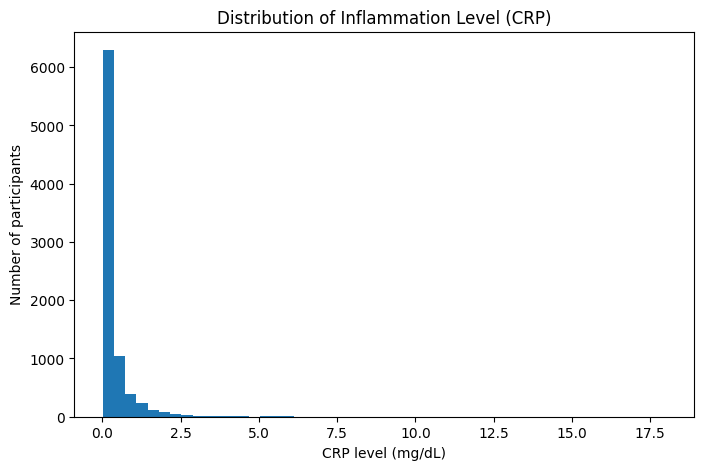

In [35]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    crp_data,
    bins=50
)

plt.xlabel("CRP level (mg/dL)")
plt.ylabel("Number of participants")
plt.title("Distribution of Inflammation Level (CRP)")

plt.show()

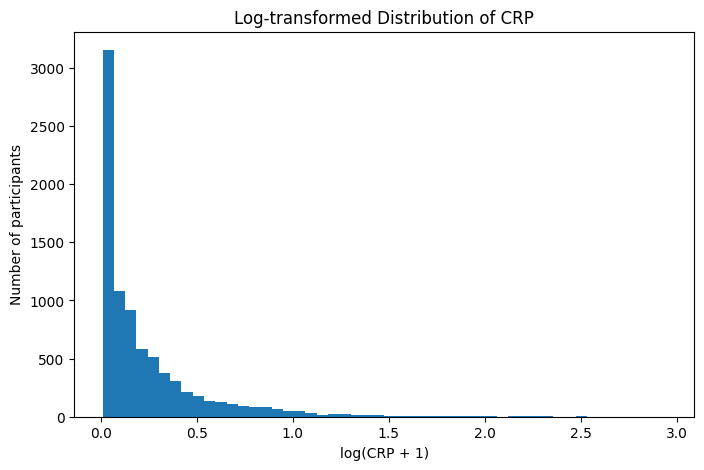

In [36]:
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(crp_data),
    bins=50
)

plt.xlabel("log(CRP + 1)")
plt.ylabel("Number of participants")
plt.title("Log-transformed Distribution of CRP")

plt.show()